In [2]:
import sys
import os
sys.path.append(os.path.abspath(".."))
from src.config import *
from src.io import *
from src.procesamiento import *
from src.visualizacion import *
from src.funciones_complejas import *

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import ast
import numpy as np

In [3]:
# CONFIGURACIÓN Y CARGA DE DATOS
############################################################

trayectorias = pd.read_excel(RUTA_EXCEL, sheet_name=2)
df_pacientes = pd.read_excel(RUTA_EXCEL, sheet_name=0) 

# --- NUEVO: AGRUPAR TRAYECTORIAS LARGAS PARA LOS TOPS ---

# Creamos una columna nueva para no romper los gráficos de saltos individuales
trayectorias['ruta_para_top'] = trayectorias['ruta_complejidad_str'].apply(agrupar_trayectorias_largas)


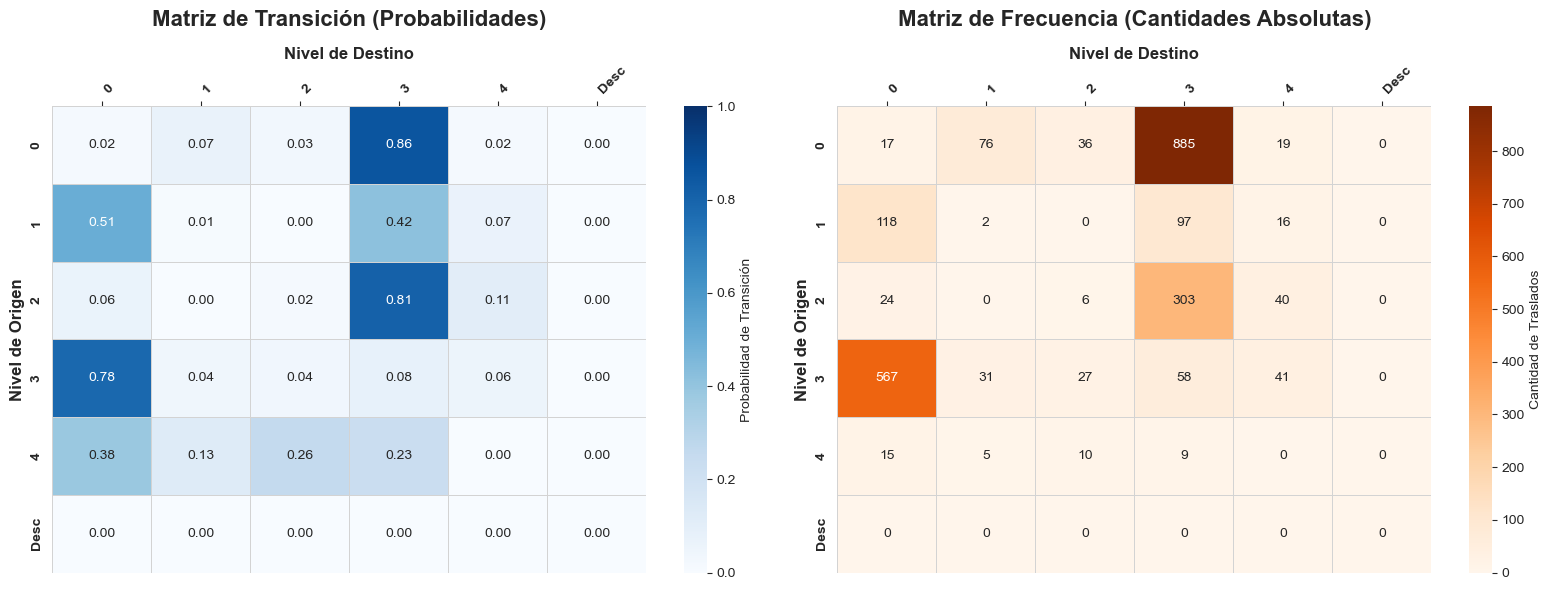

In [4]:
# GRÁFICO 1: MATRICES Y HEATMAPS
############################################################
# Este usa la original para no romper la contabilidad de tramo a tramo
df_cantidades, df_probabilidades, transiciones = calcular_matrices_transicion(trayectorias['ruta_complejidad_str'])
graficar_heatmaps(df_probabilidades, df_cantidades)


📌 RESUMEN DE COBERTURA DEL TOP 10 (TRAYECTORIAS)
Total de pacientes con traslados válidos: 27295
Pacientes DENTRO del Top 10: 26767 (98.1%)
Pacientes FUERA del Top 10:  528 (1.9%)



c:\Users\micag\Documents\RedesHospitales\src\visualizacion.py:921: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=x_col, y=y_col, palette=palette, ax=ax)


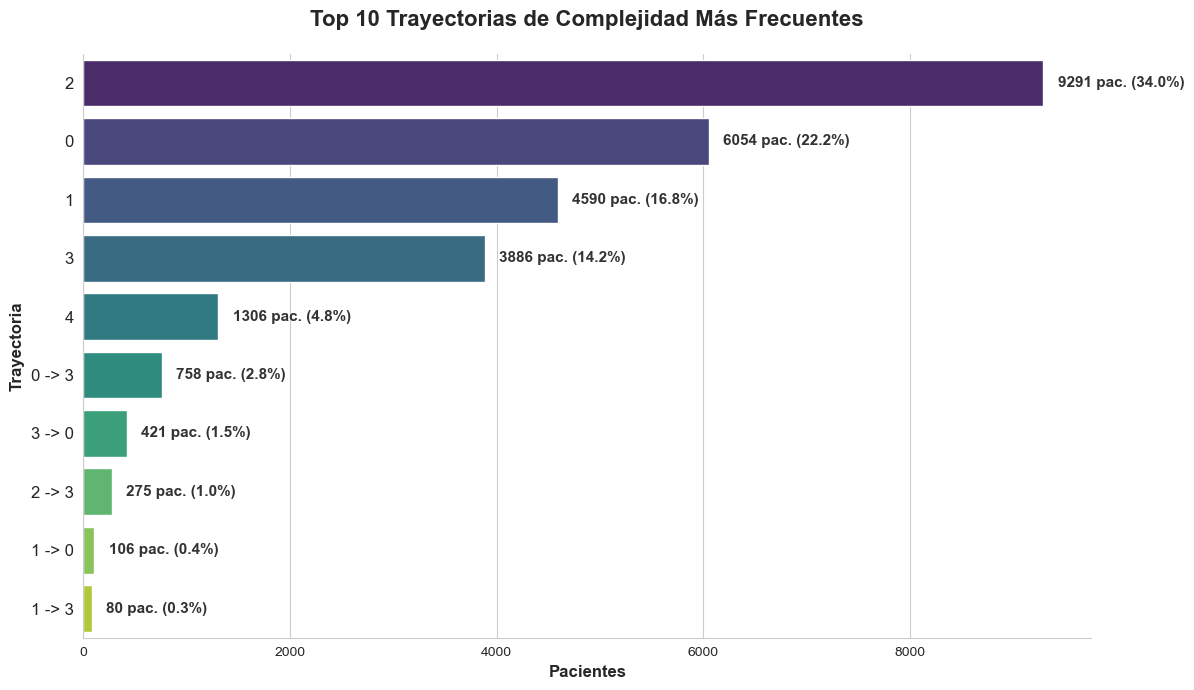

In [5]:
# GRÁFICO 2: TOP 10 TRAYECTORIAS COMPLETAS
############################################################
# AHORA USA LA COLUMNA AGRUPADA ('ruta_para_top')
top_10 = trayectorias['ruta_para_top'].value_counts().head(10).reset_index()
top_10.columns = ['Ruta', 'Frecuencia']

# Calculamos totales para el porcentaje
total_validos = len(trayectorias.dropna(subset=['ruta_para_top']))
top_10['Porcentaje'] = (top_10['Frecuencia'] / total_validos) * 100

# --- NUEVO: CALCULAR QUÉ QUEDA AFUERA DEL TOP 10 ---
pacientes_en_top10 = top_10['Frecuencia'].sum()
pacientes_fuera = total_validos - pacientes_en_top10
porcentaje_fuera = (pacientes_fuera / total_validos) * 100

print("\n" + "="*50)
print("📌 RESUMEN DE COBERTURA DEL TOP 10 (TRAYECTORIAS)")
print("="*50)
print(f"Total de pacientes con traslados válidos: {total_validos}")
print(f"Pacientes DENTRO del Top 10: {pacientes_en_top10} ({(100 - porcentaje_fuera):.1f}%)")
print(f"Pacientes FUERA del Top 10:  {pacientes_fuera} ({porcentaje_fuera:.1f}%)")
print("="*50 + "\n")
# ---------------------------------------------------

graficar_top_10(
    df=top_10, x_col='Frecuencia', y_col='Ruta',
    titulo="Top 10 Trayectorias de Complejidad Más Frecuentes",
    xlabel="Pacientes", ylabel="Trayectoria", sufijo="pac."
)


RESUMEN DE COBERTURA DEL TOP 10 (GLOBAL: CON Y SIN TRASLADOS)
Total de pacientes en el sistema: 27295
Pacientes DENTRO del Top 10: 26767 (98.1%)
Pacientes FUERA del Top 10:  528 (1.9%)



c:\Users\micag\Documents\RedesHospitales\src\visualizacion.py:921: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=x_col, y=y_col, palette=palette, ax=ax)


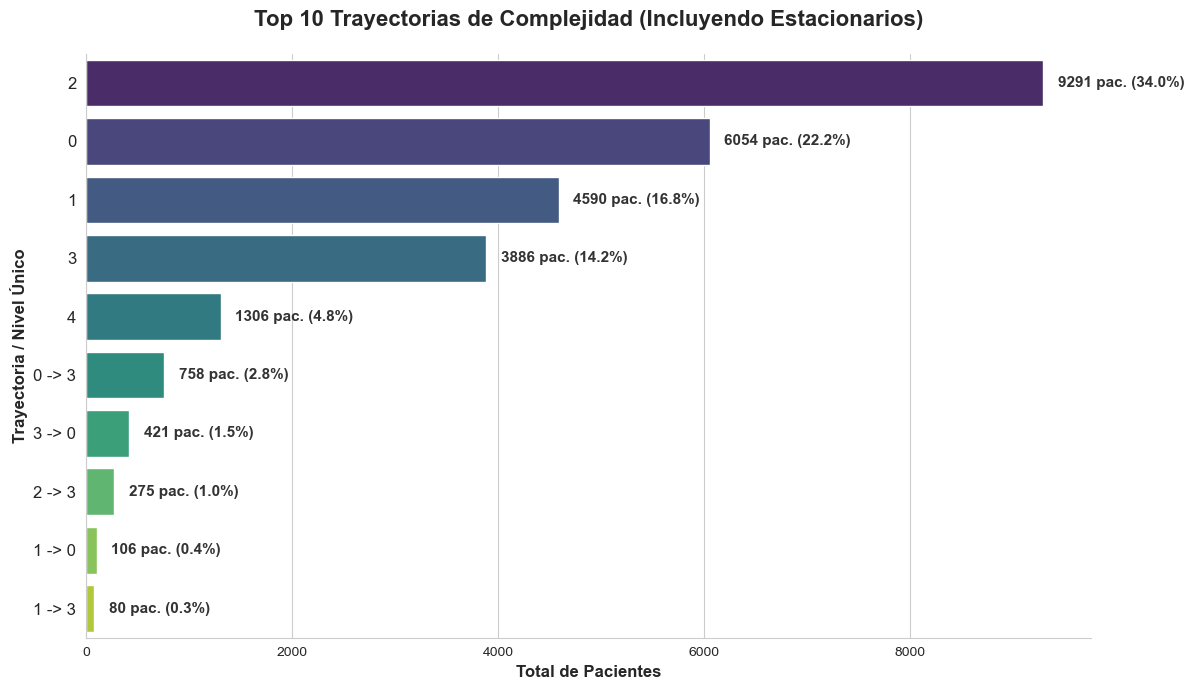

In [6]:
# new: TOP 10 TRAYECTORIAS COMPLETAS (INCLUYENDO SIN TRASLADOS)
############################################################

# 1. Nombres de las columnas clave (Reemplazar si son distintos)
columna_id = 'paciente_id'
columna_hospital = 'hospital_origen' # Columna en df_pacientes con el nombre del hospital

# 2. Cargar el archivo de hospitales y complejidades
# Asegurate de poner la ruta correcta a tu archivo CSV
df_hospitales = pd.read_csv('../data/hospitales_coordenadas.csv', encoding='utf-8') 
# Nota: Si te da error de lectura, podés probar con encoding='latin1'

# 3. Separar a los pacientes: con traslado y sin traslado
pacientes_con_traslado = trayectorias[columna_id].dropna().unique()
df_sin_traslados = df_pacientes[~df_pacientes[columna_id].isin(pacientes_con_traslado)].copy()

# 4. Cruzar (Merge) df_sin_traslados con df_hospitales para traer la 'complejidad'
# Esto busca el nombre del hospital en df_sin_traslados y le pega la complejidad que figura en el CSV
df_sin_traslados = df_sin_traslados.merge(
    df_hospitales[['Nombre Hospital', 'complejidad']], # Solo traemos las columnas que nos importan
    left_on=columna_hospital, 
    right_on='Nombre Hospital', 
    how='left'
)

# 5. Asignar la "ruta" de un solo paso (ej: "Alta", "Media", etc.)
# Llenamos con "Desconocida" por si algún hospital de df_pacientes no estaba escrito igual en el CSV
df_sin_traslados['ruta_complejidad_str'] = df_sin_traslados['complejidad'].fillna('Desconocida').astype(str)
df_sin_traslados['ruta_complejidad_str'] = df_sin_traslados['ruta_complejidad_str'].str.replace('.0', '', regex=False)


# 6. Unir ambos universos en un solo DataFrame
todas_las_trayectorias = pd.concat([
    trayectorias[[columna_id, 'ruta_complejidad_str']],
    df_sin_traslados[[columna_id, 'ruta_complejidad_str']]
], ignore_index=True)

# 7. AHORA USA LA COLUMNA AGRUPADA ('ruta_para_top') SOBRE EL TOTAL
todas_las_trayectorias['ruta_para_top'] = todas_las_trayectorias['ruta_complejidad_str'].apply(agrupar_trayectorias_largas)

top_10 = todas_las_trayectorias['ruta_para_top'].value_counts().head(10).reset_index()
top_10.columns = ['Ruta', 'Frecuencia']

# Calculamos totales para el porcentaje sobre el universo TOTAL (con y sin traslados)
total_validos_global = len(todas_las_trayectorias.dropna(subset=['ruta_para_top']))
top_10['Porcentaje'] = (top_10['Frecuencia'] / total_validos_global) * 100

# --- RESUMEN DE COBERTURA ---
pacientes_en_top10 = top_10['Frecuencia'].sum()
pacientes_fuera = total_validos_global - pacientes_en_top10
porcentaje_fuera = (pacientes_fuera / total_validos_global) * 100

print("\n" + "="*50)
print("RESUMEN DE COBERTURA DEL TOP 10 (GLOBAL: CON Y SIN TRASLADOS)")
print("="*50)
print(f"Total de pacientes en el sistema: {total_validos_global}")
print(f"Pacientes DENTRO del Top 10: {pacientes_en_top10} ({(100 - porcentaje_fuera):.1f}%)")
print(f"Pacientes FUERA del Top 10:  {pacientes_fuera} ({porcentaje_fuera:.1f}%)")
print("="*50 + "\n")
# ---------------------------------------------------

graficar_top_10(
    df=top_10, x_col='Frecuencia', y_col='Ruta',
    titulo="Top 10 Trayectorias de Complejidad (Incluyendo Estacionarios)",
    xlabel="Total de Pacientes", ylabel="Trayectoria / Nivel Único", sufijo="pac."
)

c:\Users\micag\Documents\RedesHospitales\src\visualizacion.py:921: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=x_col, y=y_col, palette=palette, ax=ax)


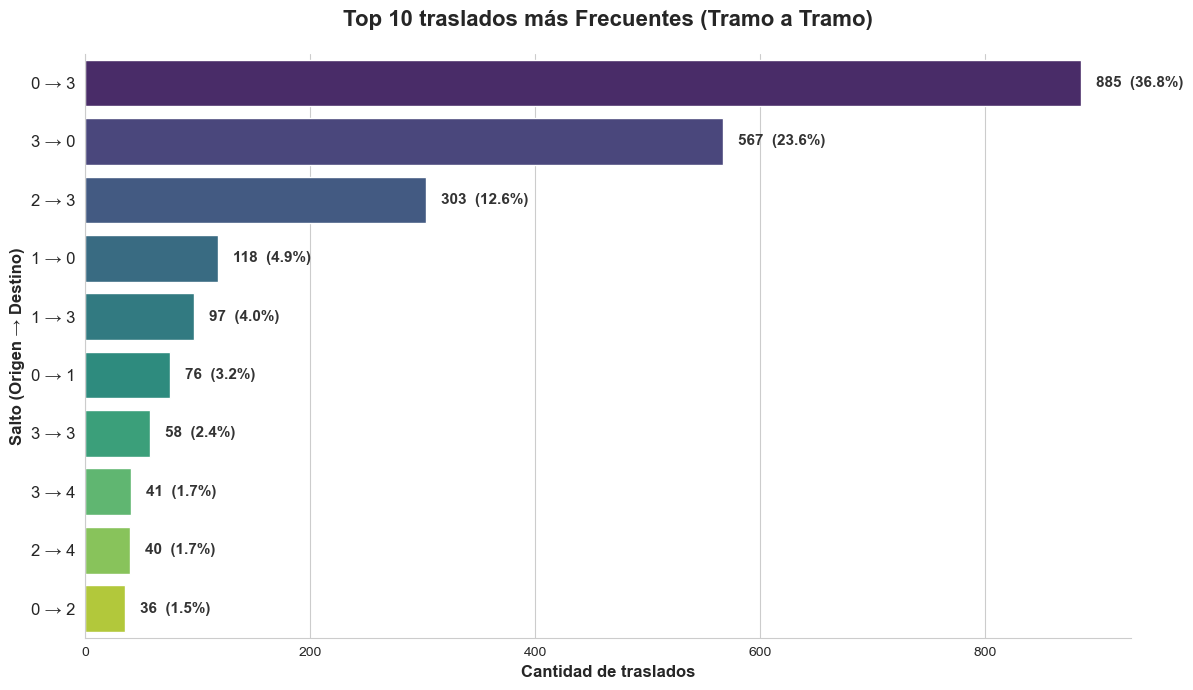

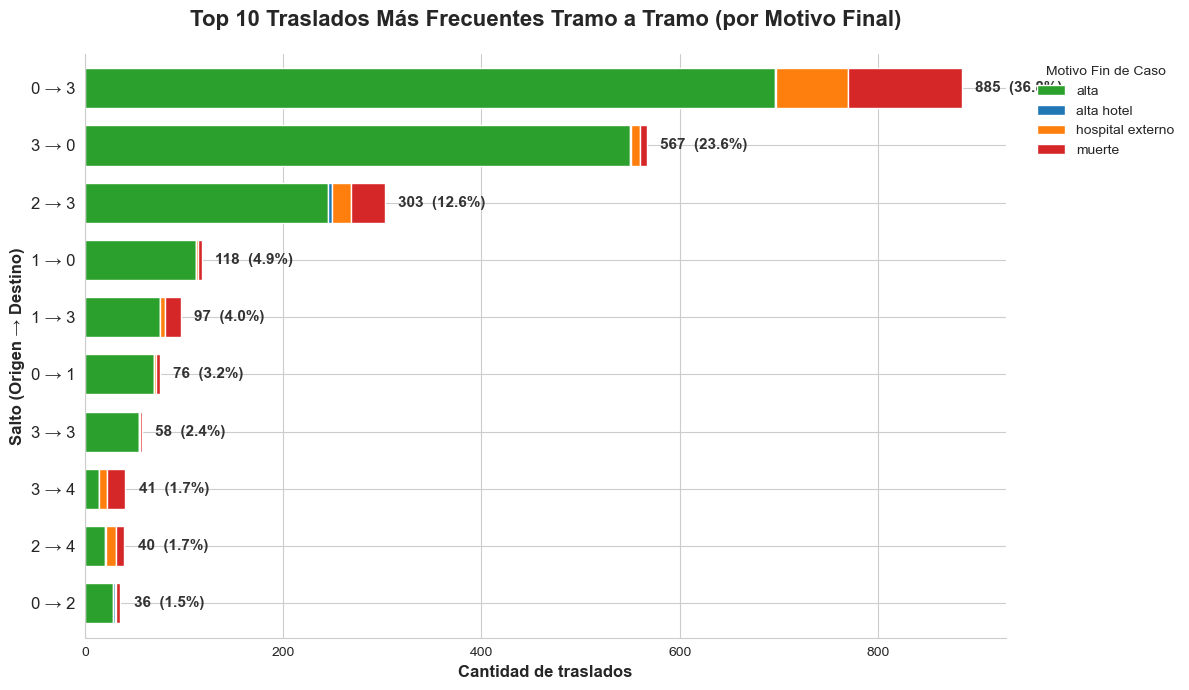

In [7]:
# GRÁFICO 3: TOP 10 SALTOS INDIVIDUALES
############################################################
df_saltos = pd.DataFrame(transiciones.items(), columns=['Salto_Tupla', 'Frecuencia'])
df_saltos['Salto'] = df_saltos['Salto_Tupla'].apply(lambda x: f"{x[0]} → {x[1]}")
top_10_saltos = df_saltos.sort_values(by='Frecuencia', ascending=False).head(10).reset_index(drop=True)
top_10_saltos['Porcentaje'] = (top_10_saltos['Frecuencia'] / df_saltos['Frecuencia'].sum()) * 100

graficar_top_10(
    df=top_10_saltos, x_col='Frecuencia', y_col='Salto',
    titulo="Top 10 traslados más Frecuentes (Tramo a Tramo)",
    xlabel="Cantidad de traslados", ylabel="Salto (Origen → Destino)", sufijo=""
)


# PREPARACIÓN MOTIVOS (Asegúrate de que trayectorias tenga la columna 'motivo_fin_caso')
trayectorias['motivo_fin_caso'] = trayectorias['motivo_fin_caso'].fillna('otro/desconocido')
trayectorias['motivo_fin_caso'] = trayectorias['motivo_fin_caso'].str.lower().str.strip() 



# GRÁFICO 3: TOP 10 SALTOS INDIVIDUALES APILADOS
############################################################
saltos_con_motivo = []
for _, row in trayectorias.dropna(subset=['ruta_complejidad_str']).iterrows():
    ruta = str(row['ruta_complejidad_str'])
    motivo = row['motivo_fin_caso']
    nodos = [n.strip() for n in ruta.split('->')]
    
    for i in range(len(nodos)-1):
        salto = f"{nodos[i]} → {nodos[i+1]}"
        saltos_con_motivo.append({'Salto': salto, 'motivo_fin_caso': motivo})

df_saltos = pd.DataFrame(saltos_con_motivo)
total_saltos = len(df_saltos)
top_10_saltos_idx = df_saltos['Salto'].value_counts().head(10).index

df_saltos_top10 = df_saltos[df_saltos['Salto'].isin(top_10_saltos_idx)]
pivot_saltos = df_saltos_top10.groupby(['Salto', 'motivo_fin_caso']).size().unstack(fill_value=0)
pivot_saltos = pivot_saltos.reindex(top_10_saltos_idx[::-1])

graficar_top_10_apilado(
    df_pivot=pivot_saltos,
    titulo="Top 10 Traslados Más Frecuentes Tramo a Tramo (por Motivo Final)",
    xlabel="Cantidad de traslados", 
    ylabel="Salto (Origen → Destino)", 
    total_general=total_saltos,
    sufijo=""
)

c:\Users\micag\Documents\RedesHospitales\src\visualizacion.py:921: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=x_col, y=y_col, palette=palette, ax=ax)
c:\Users\micag\Documents\RedesHospitales\src\visualizacion.py:931: UserWarning: Glyph 10132 (\N{HEAVY WIDE-HEADED RIGHTWARDS ARROW}) missing from font(s) Arial.
  plt.tight_layout(rect=[0, 0, 1, 0.95])
c:\Users\micag\anaconda3\envs\redes\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10132 (\N{HEAVY WIDE-HEADED RIGHTWARDS ARROW}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


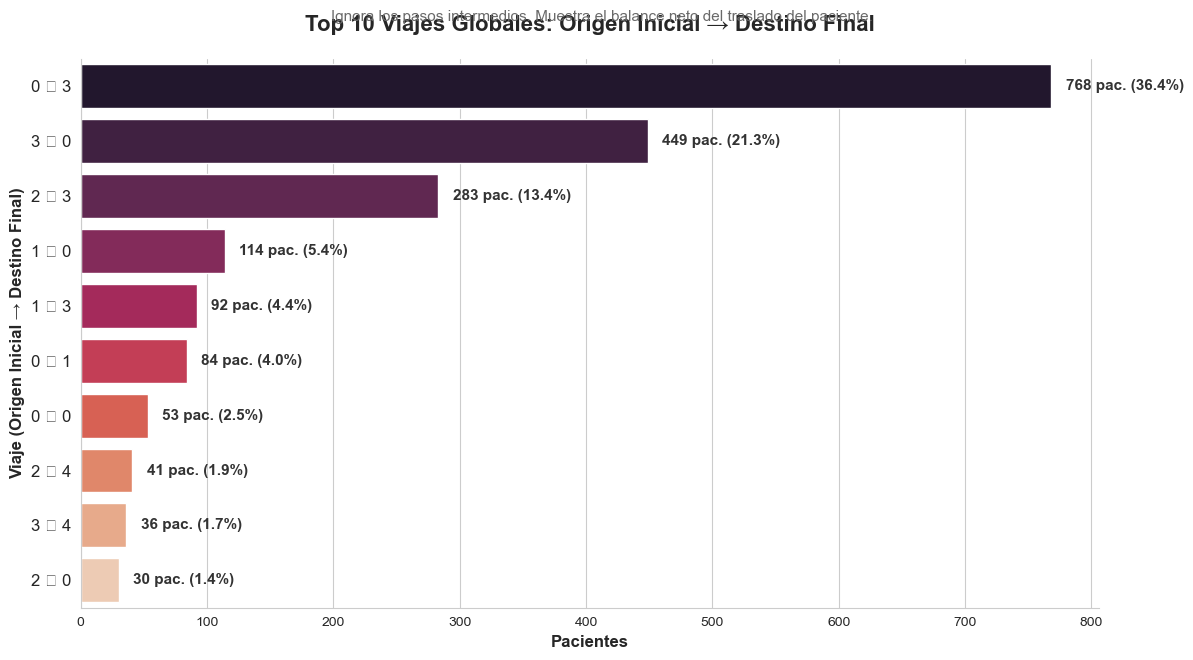

In [8]:
# GRÁFICO 4: VIAJE GLOBAL (ORIGEN ➔ DESTINO)
# ============================================================

# Creamos una función simple para extraer el primer y último eslabón del texto
def obtener_origen_destino(ruta_str):
    if pd.isna(ruta_str):
        return None
    # Cortamos el texto por la flecha
    nodos = str(ruta_str).split(' -> ')
    
    # Si tiene más de 1 nodo (o sea, si realmente viajó)
    if len(nodos) > 1:
        return f"{nodos[0]} ➔ {nodos[-1]}"
    else:
        return None # Ignoramos a los que nunca se movieron

# Aplicamos nuestra nueva función a la columna correcta
trayectorias['viaje_global'] = trayectorias['ruta_complejidad_str'].apply(obtener_origen_destino)

# El resto sigue exactamente igual
df_viajes = trayectorias.dropna(subset=['viaje_global'])
top_10_viajes = df_viajes['viaje_global'].value_counts().head(10).reset_index()
top_10_viajes.columns = ['Viaje_Global', 'Frecuencia']
top_10_viajes['Porcentaje'] = (top_10_viajes['Frecuencia'] / len(df_viajes)) * 100

graficar_top_10(
    df=top_10_viajes, x_col='Frecuencia', y_col='Viaje_Global',
    titulo="Top 10 Viajes Globales: Origen Inicial → Destino Final",
    xlabel="Pacientes", ylabel="Viaje (Origen Inicial → Destino Final)", sufijo="pac.",
    palette="rocket",
    subtitulo="Ignora los pasos intermedios. Muestra el balance neto del traslado del paciente."
)

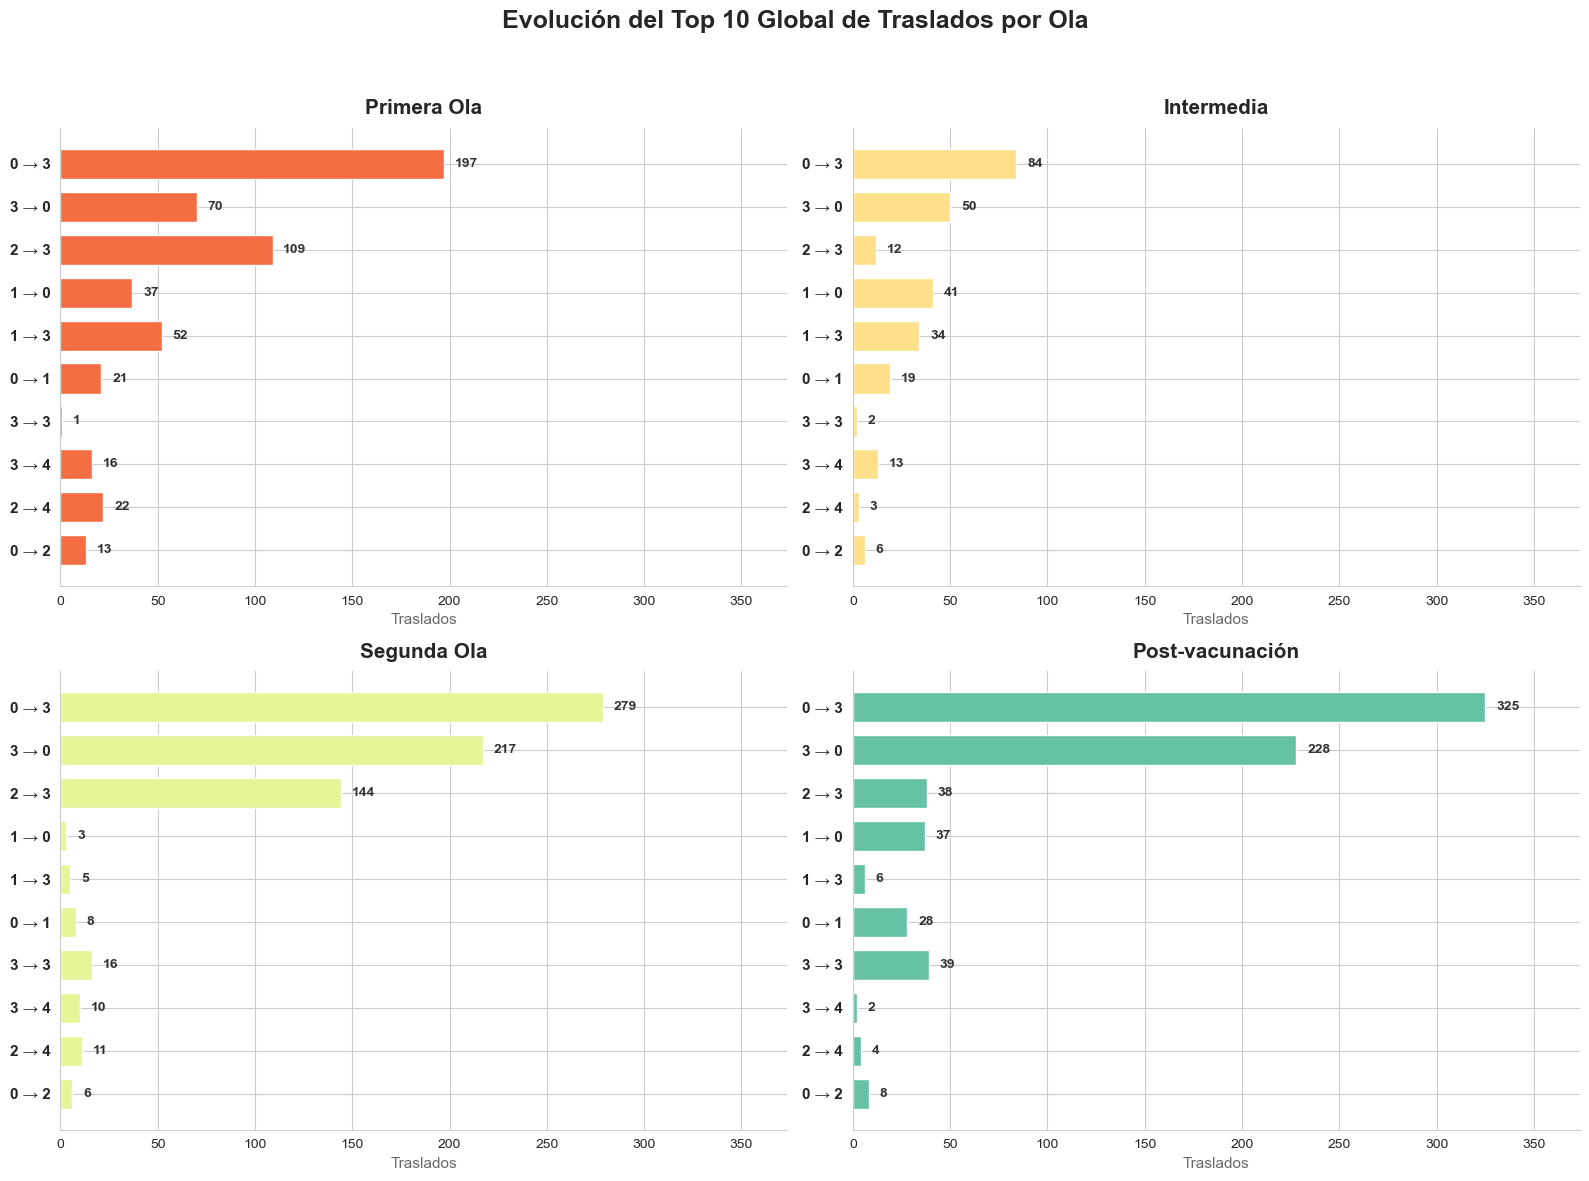

In [9]:
# GRÁFICO 5: ANÁLISIS TEMPORAL (GRILLA POR OLAS COVID)
# ============================================================

# USAMOS EL NOMBRE NUEVO: fecha_ingreso_red
trayectorias['Periodo_Covid'] = trayectorias['fecha_ingreso_red'].apply(lambda x: asignar_periodo(x, PERIODOS))

saltos_temporales = []
for _, row in trayectorias.dropna(subset=['ruta_complejidad_str']).iterrows():
    # El split('->') y strip() manejan perfecto nuestro nuevo formato "0 -> 3"
    ruta = [n.strip() for n in str(row['ruta_complejidad_str']).split('->')]
    
    if len(ruta) > 1:
        for i in range(len(ruta) - 1):
            saltos_temporales.append({
                'Salto': f"{ruta[i]} → {ruta[i+1]}",
                'Periodo': row['Periodo_Covid']
            })

df_saltos_temp = pd.DataFrame(saltos_temporales)
nombres_periodos = [p[0] for p in PERIODOS]
df_saltos_temp = df_saltos_temp[df_saltos_temp['Periodo'].isin(nombres_periodos)]

top_10_nombres = df_saltos_temp['Salto'].value_counts().head(10).index
df_top10_temp = df_saltos_temp[df_saltos_temp['Salto'].isin(top_10_nombres)]

pivot_periodos = pd.crosstab(df_top10_temp['Salto'], df_top10_temp['Periodo'])
pivot_periodos['Total'] = pivot_periodos.sum(axis=1)
pivot_periodos = pivot_periodos.sort_values('Total', ascending=True).drop(columns=['Total'])

orden_columnas_existentes = [p for p in nombres_periodos if p in pivot_periodos.columns]
pivot_periodos = pivot_periodos[orden_columnas_existentes]

graficar_grilla_periodos(pivot_periodos, orden_columnas_existentes)

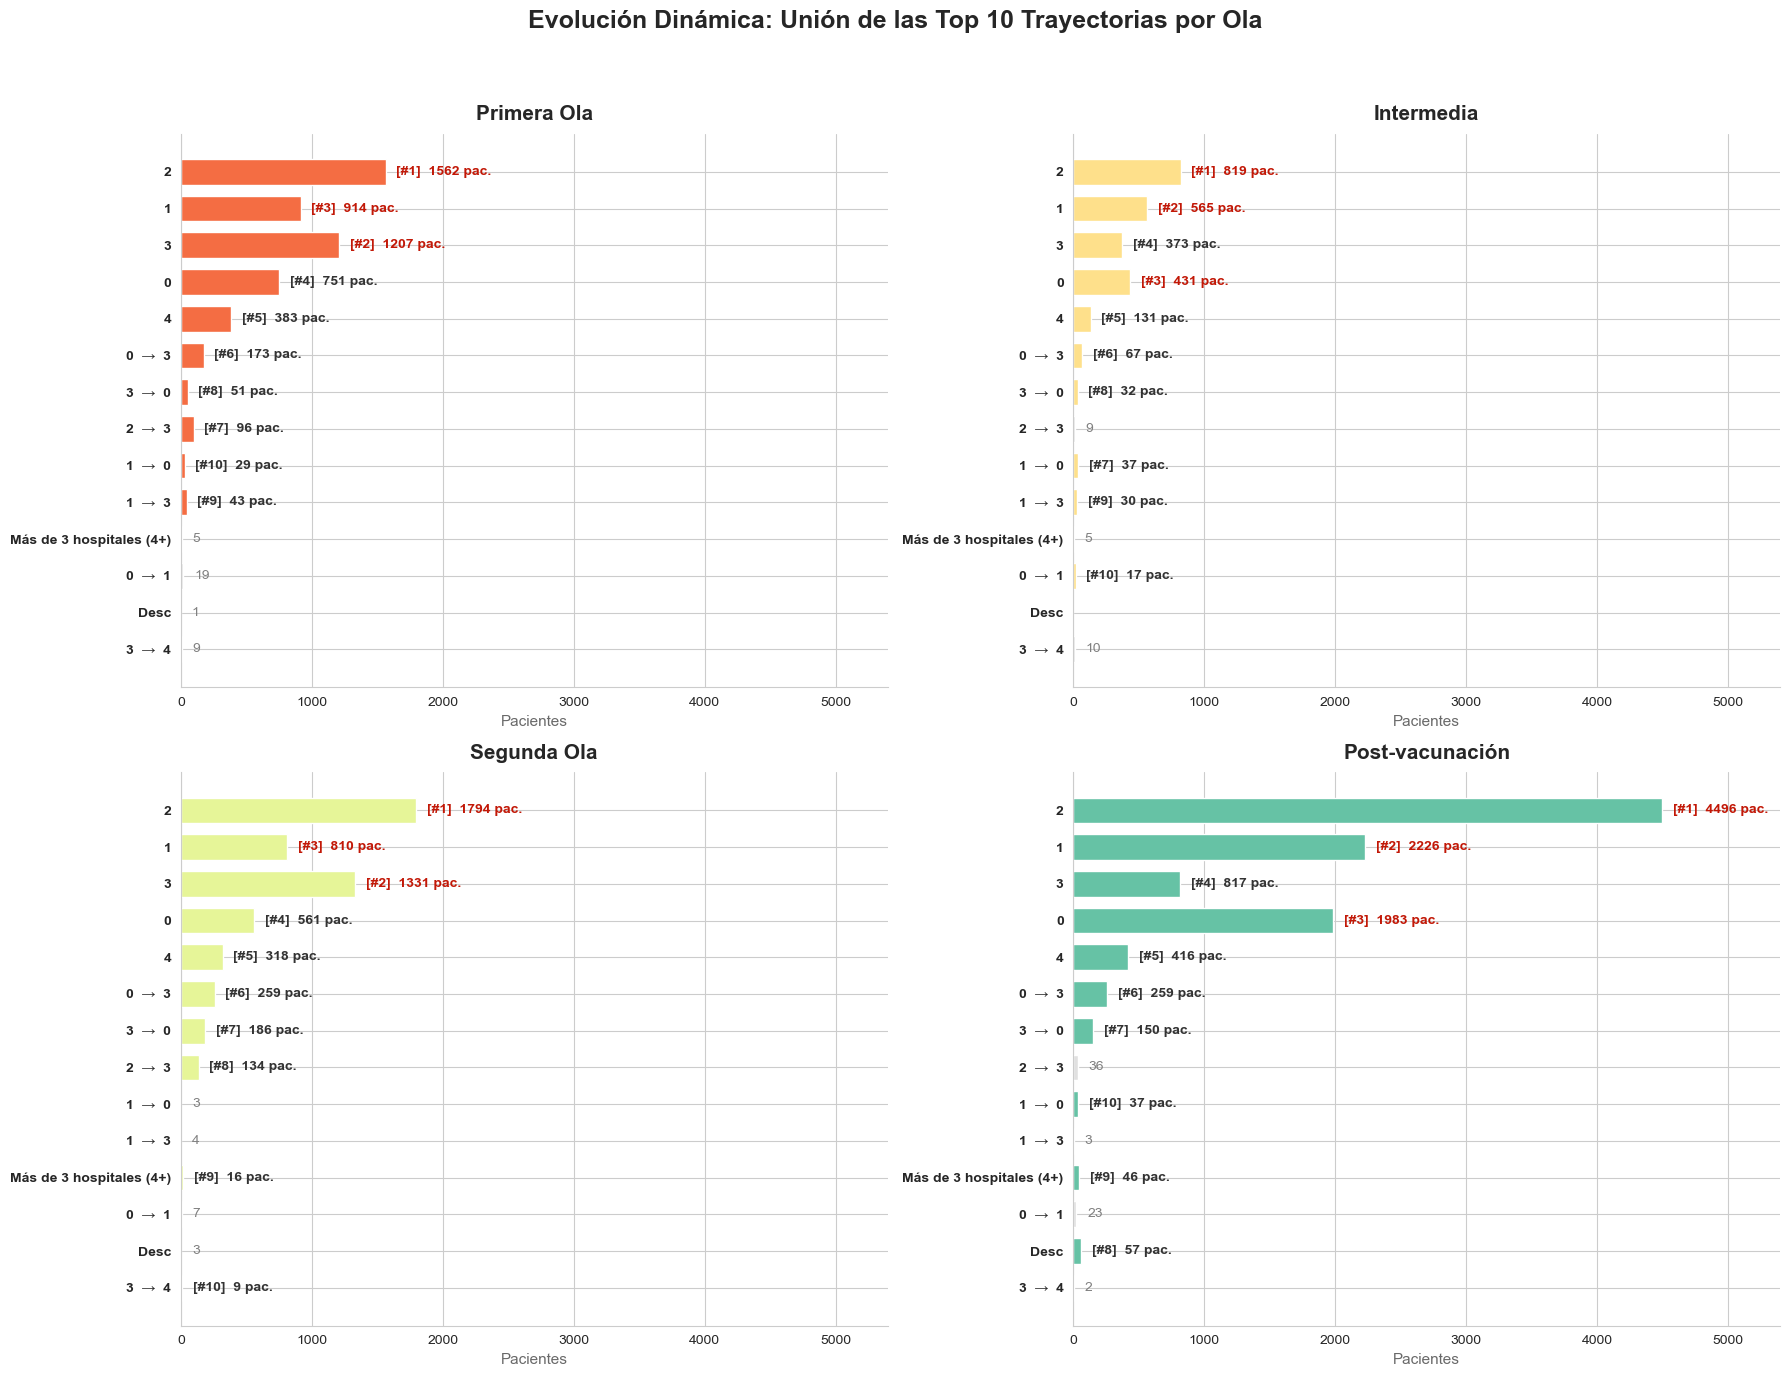

In [10]:
# GRÁFICO 6: TRAYECTORIAS COMPLETAS CON RANKING DINÁMICO (MODIFICADO)
############################################################
nombres_periodos = [p[0] for p in PERIODOS]

# AHORA USA LA COLUMNA AGRUPADA ('ruta_para_top')
df_trayectorias_validas = trayectorias[
    (trayectorias['Periodo_Covid'].isin(nombres_periodos)) & 
    (trayectorias['ruta_para_top'].notna())
].copy()

# Reemplaza la flecha solo si no es la categoría nueva que agrupa textos
df_trayectorias_validas['ruta_formateada'] = df_trayectorias_validas['ruta_para_top'].apply(
    lambda x: str(x).replace('->', ' → ') if 'hospitales' not in str(x) else str(x)
)

top_por_periodo = {}
rutas_union = set()

for periodo in nombres_periodos:
    df_periodo = df_trayectorias_validas[df_trayectorias_validas['Periodo_Covid'] == periodo]
    conteos_periodo = df_periodo['ruta_formateada'].value_counts().head(N_TOP)
    top_por_periodo[periodo] = conteos_periodo
    rutas_union.update(conteos_periodo.index)

volumen_global = df_trayectorias_validas[
    df_trayectorias_validas['ruta_formateada'].isin(rutas_union)
]['ruta_formateada'].value_counts(ascending=True)
rutas_ordenadas = volumen_global.index.tolist()

df_cantidades = pd.DataFrame(0, index=rutas_ordenadas, columns=nombres_periodos)
df_rankings = pd.DataFrame(np.nan, index=rutas_ordenadas, columns=nombres_periodos)

for periodo in nombres_periodos:
    cantidades_totales_periodo = df_trayectorias_validas[
        df_trayectorias_validas['Periodo_Covid'] == periodo
    ]['ruta_formateada'].value_counts()
    
    for ruta in rutas_ordenadas:
        df_cantidades.at[ruta, periodo] = cantidades_totales_periodo.get(ruta, 0)
    
    if periodo in top_por_periodo:
        top_rutas = top_por_periodo[periodo].index
        for rank, ruta in enumerate(top_rutas, 1): 
            df_rankings.at[ruta, periodo] = rank

graficar_grilla_trayectorias_dinamico(df_cantidades, df_rankings, nombres_periodos, n_top=N_TOP)

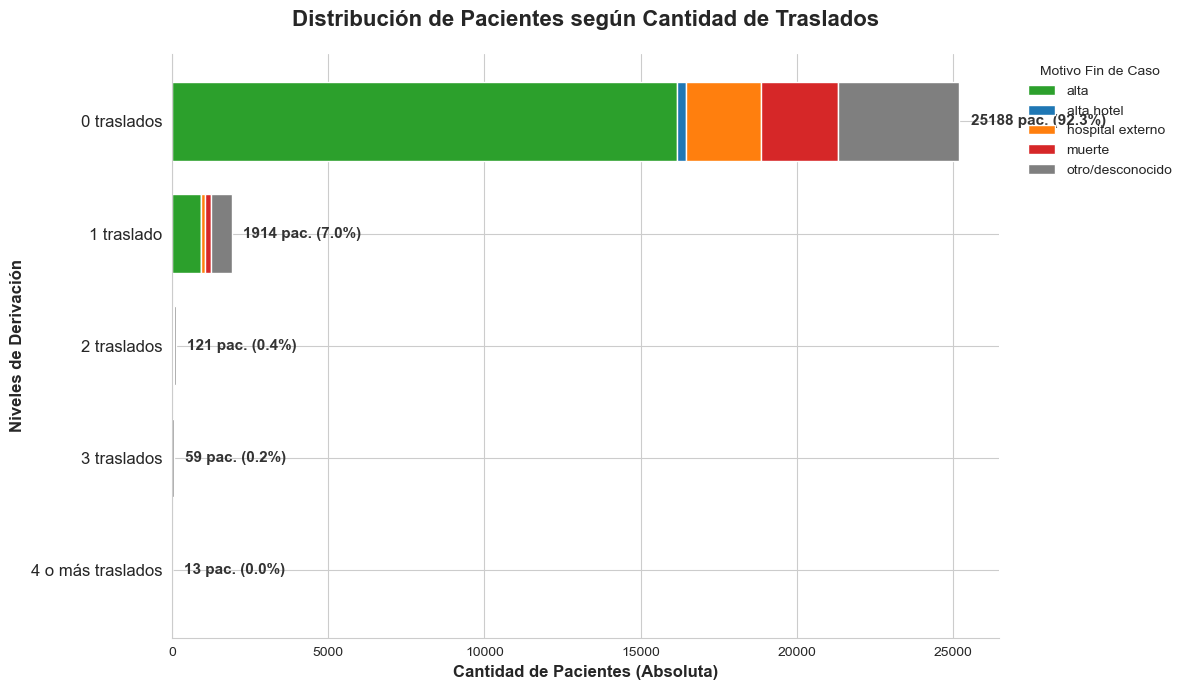

In [11]:
# GRÁFICO 7: DISTRIBUCIÓN DE CANTIDAD DE TRASLADOS (CON 0 TRASLADOS) APILADO
############################################################
# 1. Rescatamos TODOS los pacientes desde df_pacientes (Hoja 1)
df_pacientes['motivo_egreso'] = df_pacientes['motivo_egreso'].fillna('otro/desconocido')

# Sacamos el último registro de cada paciente para saber cómo terminó su caso
ultimo_motivo = df_pacientes.groupby('paciente_id')['motivo_egreso'].last().reset_index()

# Aplicamos las reglas de motivos para que coincidan con los colores
condiciones_motivo = [
    ultimo_motivo['motivo_egreso'].str.lower() == 'alta-domiciliaria',
    ultimo_motivo['motivo_egreso'].str.lower() == 'muerte',
    ultimo_motivo['motivo_egreso'].str.lower() == 'traslado-otro',
    ultimo_motivo['motivo_egreso'].str.lower() == 'traslado-extra-sanitario'
]
resultados_motivo = ['alta', 'muerte', 'hospital externo', 'alta hotel']
ultimo_motivo['motivo_fin_caso'] = np.select(condiciones_motivo, resultados_motivo, default='otro/desconocido')

# 2. Traemos la cantidad de traslados de la hoja de trayectorias
traslados_count = trayectorias[['paciente_id', 'cantidad_traslados']].drop_duplicates()

# Unimos. El que no cruzó (no está en trayectorias) es porque tuvo 0 traslados
df_distribucion = ultimo_motivo.merge(traslados_count, on='paciente_id', how='left')
df_distribucion['cantidad_traslados'] = df_distribucion['cantidad_traslados'].fillna(0)

# 3. Agrupamos en las 5 barras que pediste: 0, 1, 2, 3, y 4 o más
def categorizar_cantidad(cant):
    if cant >= 4:
        return '4 o más traslados'
    elif cant == 1:
        return '1 traslado'
    else:
        return f"{int(cant)} traslados"

df_distribucion['grupo_traslados'] = df_distribucion['cantidad_traslados'].apply(categorizar_cantidad)

# 4. Agrupamos y pivoteamos para el gráfico
pivot_distribucion = df_distribucion.groupby(['grupo_traslados', 'motivo_fin_caso']).size().unstack(fill_value=0)

# Reordenamos el índice para que en el gráfico queden ordenados de arriba hacia abajo lógicamente
orden_grupos = ['4 o más traslados', '3 traslados', '2 traslados', '1 traslado', '0 traslados']
# Filtramos solo los que existan por si en alguna muestra no hay de 4, etc.
orden_grupos = [g for g in orden_grupos if g in pivot_distribucion.index] 
pivot_distribucion = pivot_distribucion.reindex(orden_grupos)

# 5. Graficamos usando tu misma función
graficar_top_10_apilado(
    df_pivot=pivot_distribucion,
    titulo="Distribución de Pacientes según Cantidad de Traslados",
    xlabel="Cantidad de Pacientes (Absoluta)",
    ylabel="Niveles de Derivación",
    total_general=len(df_distribucion),
    sufijo="pac."
)

In [12]:
# TABLA RESUMEN CLÍNICA AVANZADA (ESTACIONARIOS VS TRASLADOS)
# ==========================================================

# 1. Preparar un DataFrame analítico unificado
df_analisis = df_pacientes.copy()

# Parsear fechas de forma segura para calcular estadías
df_analisis['fecha_ingreso_dt'] = pd.to_datetime(df_analisis['fecha_ingreso'], errors='coerce')
df_analisis['fecha_egreso_dt'] = pd.to_datetime(df_analisis['fecha_egreso'], errors='coerce')
df_analisis['dias_estadia'] = (df_analisis['fecha_egreso_dt'] - df_analisis['fecha_ingreso_dt']).dt.days

# Asignar período COVID general a cada paciente
df_analisis['Periodo_Covid'] = df_analisis['fecha_ingreso_dt'].apply(
    lambda x: asignar_periodo(x, PERIODOS) if pd.notna(x) else 'Sin Dato'
)

# --- ESTA ES LA LÍNEA NUEVA PARA ARREGLAR EL ERROR DE LA EDAD ---
df_analisis['edad'] = pd.to_numeric(df_analisis['edad'], errors='coerce')
# ----------------------------------------------------------------

# Traer la cantidad de traslados para saber si se movió o no
traslados_info = trayectorias[['paciente_id', 'cantidad_traslados']].drop_duplicates(subset=['paciente_id'])
df_analisis = df_analisis.merge(traslados_info, on='paciente_id', how='left')

# Crear flags (Banderas booleanas)
df_analisis['es_trasladado'] = df_analisis['cantidad_traslados'].notna()
df_analisis['cantidad_traslados'] = df_analisis['cantidad_traslados'].fillna(0)

# Limpiar variables clínicas
df_analisis['requiere_arm_bool'] = df_analisis['requiere_arm'].astype(str).str.lower().isin(['si', 'sí', 'true', '1'])
df_analisis['motivo_egreso_clean'] = df_analisis['motivo_egreso'].astype(str).str.lower().str.strip()
df_analisis['fallecido'] = df_analisis['motivo_egreso_clean'] == 'muerte'
df_analisis['alta_exitosa'] = df_analisis['motivo_egreso_clean'].isin(['alta', 'alta-domiciliaria', 'alta hotel'])

# 2. Estructura de la Tabla
nombres_periodos = [p[0] for p in PERIODOS]
columnas_tabla = nombres_periodos + ['Total Global']

metricas = [
    "PERFIL CLÍNICO",
    "Edad Promedio (Años)",
    "Requirió Respirador - ARM (\\%)",
    "Estadía Promedio (Días)",
    "DINÁMICA DE RED",
    "Pacientes hiper-movilizados (≥2 traslados)",
    "DESENLACES CLÍNICOS",
    "Mortalidad (\\%)",
    "Tasa de Altas (\\%)"
]

df_avanzado = pd.DataFrame(index=metricas, columns=columnas_tabla)

# 3. Calcular las métricas "Jugosas"
for periodo in columnas_tabla:
    
    if periodo == 'Total Global':
        df_p = df_analisis[df_analisis['Periodo_Covid'].isin(nombres_periodos)]
    else:
        df_p = df_analisis[df_analisis['Periodo_Covid'] == periodo]
        
    df_est = df_p[~df_p['es_trasladado']]
    df_tra = df_p[df_p['es_trasladado']]
    
    # Función auxiliar para armar el texto "Estacionario | Trasladado"
    def comparar(metrica_est, metrica_tra, is_pct=False, is_int=False):
        if is_int:
            return f"{int(metrica_est)} | {int(metrica_tra)}"
        elif is_pct:
            return f"{metrica_est:.1f}\\% | {metrica_tra:.1f}\\%"
        else:
            return f"{metrica_est:.1f} | {metrica_tra:.1f}"

    # Separadores visuales (vacíos)
    df_avanzado.at["PERFIL CLÍNICO", periodo] = "Fijo | Movido"
    df_avanzado.at["DINÁMICA DE RED", periodo] = "Fijo | Movido"
    df_avanzado.at["DESENLACES CLÍNICOS", periodo] = "Fijo | Movido"

    # Edad Promedio
    edad_e = df_est['edad'].mean() if len(df_est) > 0 else 0
    edad_t = df_tra['edad'].mean() if len(df_tra) > 0 else 0
    df_avanzado.at["Edad Promedio (Años)", periodo] = comparar(edad_e, edad_t)

    # Requirió ARM (%)
    arm_e = (df_est['requiere_arm_bool'].mean() * 100) if len(df_est) > 0 else 0
    arm_t = (df_tra['requiere_arm_bool'].mean() * 100) if len(df_tra) > 0 else 0
    df_avanzado.at["Requirió Respirador - ARM (\\%)", periodo] = comparar(arm_e, arm_t, is_pct=True)

    # Estadía Promedio
    estadia_e = df_est['dias_estadia'].mean() if len(df_est) > 0 else 0
    estadia_t = df_tra['dias_estadia'].mean() if len(df_tra) > 0 else 0
    df_avanzado.at["Estadía Promedio (Días)", periodo] = comparar(estadia_e, estadia_t)

    # Hiper-movilizados (solo aplica a trasladados)
    hiper = len(df_tra[df_tra['cantidad_traslados'] >= 2])
    pct_hiper = (hiper / len(df_tra) * 100) if len(df_tra) > 0 else 0
    df_avanzado.at["Pacientes hiper-movilizados (≥2 traslados)", periodo] = f"- | {hiper} ({pct_hiper:.1f}\\%)"

    # Mortalidad (%)
    muertes_e = (df_est['fallecido'].mean() * 100) if len(df_est) > 0 else 0
    muertes_t = (df_tra['fallecido'].mean() * 100) if len(df_tra) > 0 else 0
    df_avanzado.at["Mortalidad (\\%)", periodo] = comparar(muertes_e, muertes_t, is_pct=True)

    # Tasa de altas exitosas (%)
    altas_e = (df_est['alta_exitosa'].mean() * 100) if len(df_est) > 0 else 0
    altas_t = (df_tra['alta_exitosa'].mean() * 100) if len(df_tra) > 0 else 0
    df_avanzado.at["Tasa de Altas (\\%)", periodo] = comparar(altas_e, altas_t, is_pct=True)


# 4. Generar el código LaTeX
df_avanzado.index.name = "Indicador (Estacionario | Trasladado)"

print("\n" + "="*80)
print("CÓDIGO LATEX GENERADO: ANÁLISIS CLÍNICO PROFUNDO (FIJOS VS MOVIDOS)")
print("="*80 + "\n")

latex_avanzado = df_avanzado.to_latex(
    caption="Análisis comparativo de gravedad y desenlaces: Pacientes estacionarios vs. Trasladados",
    label="tab:analisis_clinico_traslados",
    column_format="l" + "c" * len(df_avanzado.columns),
    escape=False
)

# Estilado extra para resaltar los títulos de sección en LaTeX
latex_avanzado = latex_avanzado.replace('PERFIL CLÍNICO', '\\midrule \\textbf{PERFIL CLÍNICO}')
latex_avanzado = latex_avanzado.replace('DINÁMICA DE RED', '\\midrule \\textbf{DINÁMICA DE RED}')
latex_avanzado = latex_avanzado.replace('DESENLACES CLÍNICOS', '\\midrule \\textbf{DESENLACES CLÍNICOS}')

print(latex_avanzado)

df_avanzado


CÓDIGO LATEX GENERADO: ANÁLISIS CLÍNICO PROFUNDO (FIJOS VS MOVIDOS)

\begin{table}
\caption{Análisis comparativo de gravedad y desenlaces: Pacientes estacionarios vs. Trasladados}
\label{tab:analisis_clinico_traslados}
\begin{tabular}{lccccc}
\toprule
 & Primera Ola & Intermedia & Segunda Ola & Post-vacunación & Total Global \\
Indicador (Estacionario | Trasladado) &  &  &  &  &  \\
\midrule
\midrule \textbf{PERFIL CLÍNICO} & Fijo | Movido & Fijo | Movido & Fijo | Movido & Fijo | Movido & Fijo | Movido \\
Edad Promedio (Años) & 0.0 | 48.6 & 0.0 | 47.8 & 0.0 | 50.4 & 0.0 | 46.1 & 0.0 | 47.9 \\
Requirió Respirador - ARM (\%) & 0.0\% | 0.0\% & 0.0\% | 0.0\% & 0.0\% | 1.1\% & 0.0\% | 0.5\% & 0.0\% | 0.5\% \\
Estadía Promedio (Días) & 0.0 | 8.7 & 0.0 | 9.7 & 0.0 | 10.4 & 0.0 | 9.6 & 0.0 | 9.6 \\
\midrule \textbf{DINÁMICA DE RED} & Fijo | Movido & Fijo | Movido & Fijo | Movido & Fijo | Movido & Fijo | Movido \\
Pacientes hiper-movilizados (≥2 traslados) & - | 140 (2.3\%) & - | 101 (3.5\%) &

,Primera Ola,Intermedia,Segunda Ola,Post-vacunación,Total Global
Indicador (Estacionario | Trasladado),,,,,
PERFIL CLÍNICO,Fijo | Movido,Fijo | Movido,Fijo | Movido,Fijo | Movido,Fijo | Movido
Edad Promedio (Años),0.0 | 48.6,0.0 | 47.8,0.0 | 50.4,0.0 | 46.1,0.0 | 47.9
Requirió Respirador - ARM (\%),0.0\% | 0.0\%,0.0\% | 0.0\%,0.0\% | 1.1\%,0.0\% | 0.5\%,0.0\% | 0.5\%
Estadía Promedio (Días),0.0 | 8.7,0.0 | 9.7,0.0 | 10.4,0.0 | 9.6,0.0 | 9.6
DINÁMICA DE RED,Fijo | Movido,Fijo | Movido,Fijo | Movido,Fijo | Movido,Fijo | Movido
Pacientes hiper-movilizados (≥2 traslados),- | 140 (2.3\%),- | 101 (3.5\%),- | 142 (2.3\%),- | 288 (2.5\%),- | 671 (2.5\%)
DESENLACES CLÍNICOS,Fijo | Movido,Fijo | Movido,Fijo | Movido,Fijo | Movido,Fijo | Movido
Mortalidad (\%),0.0\% | 11.3\%,0.0\% | 8.9\%,0.0\% | 16.7\%,0.0\% | 6.7\%,0.0\% | 10.3\%
Tasa de Altas (\%),0.0\% | 51.0\%,0.0\% | 57.5\%,0.0\% | 50.7\%,0.0\% | 60.5\%,0.0\% | 55.7\%


In [13]:
# TABLA RESUMEN : INDICADORES CLAVE POR PERÍODO
# ==========================================================

# 0. Preparación de la base 
# ----------------------------------------------------------
df_analisis = trayectorias.copy()

# AUTO-CURACIÓN: Si df_base no existe en este notebook, lo traemos del Excel
if 'df_base' not in locals() and 'df_base' not in globals():
    print("📥 Cargando df_base desde el Excel exportado...")
    df_base = pd.read_excel("../data/revision_dfs.xlsx", sheet_name='1_Pacientes_Crudos')

# Rescatamos la edad y el ARM de df_base
if 'edad' not in df_analisis.columns:
    df_clinico = df_base.groupby('paciente_id').agg({
        'edad': 'first',
        'requiere_arm': lambda x: 1 if any(str(v).lower() in ['si', 'sí', 'true', '1'] for v in x) else 0
    }).reset_index()
    df_analisis = df_analisis.merge(df_clinico, on='paciente_id', how='left')

# ¡LA MAGIA ACÁ!: Forzamos a que la edad sea un número
df_analisis['edad'] = pd.to_numeric(df_analisis['edad'], errors='coerce')

# Asignamos el periodo
col_fecha = 'fecha_ingreso_red' if 'fecha_ingreso_red' in df_analisis.columns else 'fecha_ingreso_trayectoria'
df_analisis['Periodo_Covid'] = df_analisis[col_fecha].apply(lambda x: asignar_periodo(x, PERIODOS))

# Banderas lógicas para los cálculos matemáticos
df_analisis['es_trasladado'] = df_analisis['cantidad_traslados'] > 0
df_analisis['fallecido'] = df_analisis['motivo_fin_caso'] == 'muerte'
df_analisis['alta_exitosa'] = df_analisis['motivo_fin_caso'] == 'alta'

# Manejo seguro del respirador 
if 'requiere_arm_bool' not in df_analisis.columns:
    if 'requiere_arm' in df_analisis.columns:
        df_analisis['requiere_arm_bool'] = df_analisis['requiere_arm'].apply(lambda x: 1 if str(x) in ['1', 'True', '1.0'] else 0)
    else:
        df_analisis['requiere_arm_bool'] = 0

# 1. Preparación de métricas adicionales
# ----------------------------------------------------------
df_analisis['nivel_inicial'] = df_analisis['ruta_complejidad_str'].apply(
    lambda x: str(x).split(' -> ')[0].strip() if pd.notna(x) else '-1'
)
df_analisis['inicio_alta_complejidad'] = df_analisis['nivel_inicial'].isin(['3', '4', '3.0', '4.0'])

# 2. Definición de las 12 Preguntas/Indicadores
# ----------------------------------------------------------
indicadores = [
    "Volumen Total de Pacientes (N)",
    "Tasa de Traslado (%)",
    "Promedio de Traslados por Paciente",
    "Hiper-movilidad (% con ≥3 traslados)",
    "Edad Promedio (Años)",
    "Uso de ARM - Respirador (%)",
    "Estadía Promedio Total (Días)",
    "Mortalidad Global (%)",
    "Mortalidad en Pacientes Trasladados (%)",
    "Mortalidad en Pacientes Estacionarios (%)",
    "Tasa de Altas Exitosas (%)",
    "Ingreso inicial a Alta Complejidad (Nivel 3-4) (%)"
]

nombres_periodos = [p[0] for p in PERIODOS]
columnas_finales = nombres_periodos + ['Global']
df_resumen_ejecutivo = pd.DataFrame(index=indicadores, columns=columnas_finales)

# 3. Cálculo de la Tabla
# ----------------------------------------------------------
for col in columnas_finales:
    if col == 'Global':
        df_p = df_analisis[df_analisis['Periodo_Covid'].isin(nombres_periodos)].copy()
    else:
        df_p = df_analisis[df_analisis['Periodo_Covid'] == col].copy()
    
    if len(df_p) == 0: continue

    df_tra = df_p[df_p['es_trasladado']]
    df_est = df_p[~df_p['es_trasladado']]

    n_total = len(df_p)
    res = {
        "Volumen Total de Pacientes (N)": f"{n_total}",
        "Tasa de Traslado (%)": f"{(len(df_tra)/n_total*100):.1f}%",
        "Promedio de Traslados por Paciente": f"{df_p['cantidad_traslados'].mean():.2f}",
        "Hiper-movilidad (% con ≥3 traslados)": f"{(len(df_p[df_p['cantidad_traslados']>=3])/n_total*100):.1f}%",
        "Edad Promedio (Años)": f"{df_p['edad'].mean():.1f}", # ¡Ahora sí va a funcionar!
        "Uso de ARM - Respirador (%)": f"{(df_p['requiere_arm_bool'].mean()*100):.1f}%",
        "Estadía Promedio Total (Días)": f"{df_p['dias_estadia_total'].mean():.1f}" if 'dias_estadia_total' in df_p else "0",
        "Mortalidad Global (%)": f"{(df_p['fallecido'].mean()*100):.1f}%",
        "Mortalidad en Pacientes Trasladados (%)": f"{(df_tra['fallecido'].mean()*100):.1f}%" if len(df_tra)>0 else "0%",
        "Mortalidad en Pacientes Estacionarios (%)": f"{(df_est['fallecido'].mean()*100):.1f}%" if len(df_est)>0 else "0%",
        "Tasa de Altas Exitosas (%)": f"{(df_p['alta_exitosa'].mean()*100):.1f}%",
        "Ingreso inicial a Alta Complejidad (Nivel 3-4) (%)": f"{(df_p['inicio_alta_complejidad'].mean()*100):.1f}%"
    }
    
    for ind in indicadores:
        df_resumen_ejecutivo.at[ind, col] = res[ind]

# 4. Mostrar y Estilizar
# ----------------------------------------------------------
print("\n" + "="*40)
print("TABLA RESUMEN FINAL DE TRAYECTORIAS")
print("="*40)

display(df_resumen_ejecutivo.style.set_properties(**{'text-align': 'center'})
                             .set_table_styles([{'selector': 'th', 'props': [('background-color', '#f4f4f4'), ('color', 'black')]}]))

📥 Cargando df_base desde el Excel exportado...

TABLA RESUMEN FINAL DE TRAYECTORIAS


,Primera Ola,Intermedia,Segunda Ola,Post-vacunación,Global
Volumen Total de Pacientes (N),5371,2570,5495,10597,24033
Tasa de Traslado (%),10.3%,9.8%,12.3%,5.7%,8.7%
Promedio de Traslados por Paciente,0.11,0.11,0.13,0.07,0.10
Hiper-movilidad (% con ≥3 traslados),0.1%,0.2%,0.3%,0.4%,0.3%
Edad Promedio (Años),48.2,47.5,50.2,45.8,47.6
Uso de ARM - Respirador (%),0.0%,0.0%,1.2%,0.5%,0.5%
Estadía Promedio Total (Días),9.5,10.4,11.3,10.1,10.3
Mortalidad Global (%),12.3%,9.6%,17.9%,7.0%,10.9%
Mortalidad en Pacientes Trasladados (%),14.3%,7.6%,13.6%,3.7%,10.2%
Mortalidad en Pacientes Estacionarios (%),12.0%,9.8%,18.5%,7.2%,11.0%


In [14]:
# ==========================================================
# 🚨 AUDITORÍA DE CALIDAD DE DATOS (DATA QUALITY REPORT) 🚨
# ==========================================================

print("="*60)
print("🔍 REPORTE DE CALIDAD DE DATOS")
print("="*60)

# ---------------------------------------------------------
# 1. EL AGUJERO NEGRO: Completitud de Destinos Finales
# ---------------------------------------------------------
print("\n1. COMPLETITUD DEL DESTINO FINAL (TRASLADADOS):")
total_trasladados = len(trayectorias['paciente_id'].dropna().unique())

# Revisamos cuántos quedaron con motivo nulo o desconocido
motivos_invalidos = ['otro/desconocido', '', 'sin dato', 'nan', 'none']
trayectorias['motivo_fin_caso_str'] = trayectorias['motivo_fin_caso'].astype(str).str.lower().str.strip()

sin_destino = trayectorias['motivo_fin_caso_str'].isin(motivos_invalidos).sum()
nulos_reales = trayectorias['motivo_fin_caso'].isna().sum()
total_perdidos = sin_destino + nulos_reales
pct_perdidos = (total_perdidos / len(trayectorias)) * 100

print(f"➤ Trasladados totales en el Excel: {total_trasladados}")
print(f"➤ Pacientes cuyo estado final es desconocido/nulo: {total_perdidos} ({pct_perdidos:.1f}%)")
if pct_perdidos > 30:
    print("   ⚠️ ALERTA ROJA: Estás perdiendo el rastro de demasiados pacientes en la red.")

# ---------------------------------------------------------
# 2. CONSISTENCIA TEMPORAL: Viajes en el tiempo
# ---------------------------------------------------------
print("\n2. CONSISTENCIA DE FECHAS Y ESTADÍAS:")
df_pacientes['ingreso_dt'] = pd.to_datetime(df_pacientes['fecha_ingreso'], errors='coerce')
df_pacientes['egreso_dt'] = pd.to_datetime(df_pacientes['fecha_egreso'], errors='coerce')
df_pacientes['estadia_dias'] = (df_pacientes['egreso_dt'] - df_pacientes['ingreso_dt']).dt.days

fechas_nulas = df_pacientes['ingreso_dt'].isna().sum()
estadias_negativas = (df_pacientes['estadia_dias'] < 0).sum()
estadias_absurdas = (df_pacientes['estadia_dias'] > 180).sum() # Más de 6 meses internado

print(f"➤ Fechas de ingreso que no se pudieron leer (Nulas/Rotas): {fechas_nulas}")
print(f"➤ Estadías NEGATIVAS (fecha de egreso anterior al ingreso): {estadias_negativas}")
if estadias_negativas > 0:
    print("   ⚠️ ERROR: Hay fechas invertidas. Esto arruina los promedios de estadía.")
print(f"➤ Estadías extrañamente largas (> 6 meses): {estadias_absurdas}")

# ---------------------------------------------------------
# 3. SUB-REGISTRO CLÍNICO: La variable ARM (Respirador)
# ---------------------------------------------------------
print("\n3. VARIABLES CLÍNICAS (ARM / EDAD):")
arm_nulos = df_pacientes['requiere_arm'].isna().sum()
pct_arm_nulos = (arm_nulos / len(df_pacientes)) * 100
valores_arm = df_pacientes['requiere_arm'].dropna().unique()

print(f"➤ Celdas VACÍAS (NaN) en 'requiere_arm': {arm_nulos} ({pct_arm_nulos:.1f}%)")
print(f"➤ Cómo se escribió lo que SÍ está cargado: {valores_arm}")
if pct_arm_nulos > 50:
    print("   ⚠️ CUIDADO: El bajísimo % de ARM en tu tabla probablemente es porque nadie lo anotaba, no porque no lo usaran.")

edades_nulas = df_pacientes['edad'].isna().sum()
print(f"➤ Pacientes sin Edad cargada: {edades_nulas} ({(edades_nulas/len(df_pacientes))*100:.1f}%)")

# ---------------------------------------------------------
# 4. INTEGRIDAD REFERENCIAL: Pacientes Fantasmas
# ---------------------------------------------------------
print("\n4. CRUZAMIENTO ENTRE TABLAS:")
pacientes_en_df = set(df_pacientes['paciente_id'].dropna())
pacientes_en_trayectorias = set(trayectorias['paciente_id'].dropna())

fantasmas = pacientes_en_trayectorias - pacientes_en_df
huerfanos = pacientes_en_df - pacientes_en_trayectorias # Esto es normal (son los fijos)

print(f"➤ Pacientes que están en 'trayectorias' pero NO existen en 'df_pacientes': {len(fantasmas)}")
if len(fantasmas) > 0:
    print("   ⚠️ ERROR GRAVE: Tenés viajes de pacientes cuya ficha médica principal no existe.")

print("="*60)

🔍 REPORTE DE CALIDAD DE DATOS

1. COMPLETITUD DEL DESTINO FINAL (TRASLADADOS):
➤ Trasladados totales en el Excel: 27295
➤ Pacientes cuyo estado final es desconocido/nulo: 0 (0.0%)

2. CONSISTENCIA DE FECHAS Y ESTADÍAS:
➤ Fechas de ingreso que no se pudieron leer (Nulas/Rotas): 3168
➤ Estadías NEGATIVAS (fecha de egreso anterior al ingreso): 40
   ⚠️ ERROR: Hay fechas invertidas. Esto arruina los promedios de estadía.
➤ Estadías extrañamente largas (> 6 meses): 40

3. VARIABLES CLÍNICAS (ARM / EDAD):
➤ Celdas VACÍAS (NaN) en 'requiere_arm': 28464 (95.8%)
➤ Cómo se escribió lo que SÍ está cargado: ['No' 15 20 308 4 7 8 2 1 5 55 10 462 12 42 153 -1 3 16 9 18 13 6 19 27 22
 -6 17 23 25 -2 197 32 90 21 154 46 28 51 11 26 36 31 291 368 14 581 24
 322 49 99 97 74 38 432 66 98 73 83 62 64 92 59 37 56 267 84 29 168 328
 212 397 33 -3 -20 211 54 72 43 122 57 102 58 -5 68 40 455 126 44 41 39
 324 128 47 -4 35 424 34 61 101 30 105 -11 557 319 104 -10 106]
   ⚠️ CUIDADO: El bajísimo % de ARM en tu 